# Search policy

Working through the determinized Monte-Carlo tree search.

In [13]:
import os, sys
sys.path.insert(0, os.path.abspath('../..'))     # repo root from notebooks/policy/

import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

from agent.cards import make_deck
from agent.game import GameState
from agent.eval.harness import make_agent
from agent.policy.search import RolloutSearchPolicy, _rollout

DECK = make_deck()

## 1. The decision problem

In order to decide upon a move, we simulate many parallel "Worlds" and pick the decision which maximises EV across them.

Mathematically, the AI creates a partition of the hidden state space $\mathcal{W}$. Because it cannot compute the value of an action under uncertainty directly, it breaks the uncertainty down into a partition of certainties $w$, evaluates the exact value $V(a,w)$ in each, and uses the partition weights $P(w∣b)$ to identify optimal move $a^*$.

$$a^* = \arg\max_{a \in \mathcal{A}} \sum_{w \in \mathcal{W}} P(w \mid b) \cdot V(a, w)$$

In [14]:
# A concrete mid-game state: play a few plies of probabilistic-vs-greedy and take
# seat 0's belief about the opponent (seat 1), plus its own hand.
import random
random.seed(1)
g = GameState()
me  = make_agent("probabilistic", 0, seed=1, alpha=0.1, knock_samples=60)
opp = make_agent("greedy", 1, seed=2)
me.start(g.hands[0], g.discard_pile[-1]); opp.start(g.hands[1], g.discard_pile[-1])
agents = [me, opp]
for _ in range(6):
    if g.game_over: break
    actor, observer = agents[g.current_player], agents[1 - g.current_player]
    top = g.discard_pile[-1] if g.discard_pile else None
    rec = actor.play_turn(g)
    if observer.bs is not None and rec.drawn is not None:
        observer.saw_opponent_draw(rec.source, top)
        if not rec.knocked and rec.discard is not None:
            observer.saw_opponent_discard(rec.discard)

bs = me.bs                       # our belief P(card in opponent's hand)
my_hand = list(g.hands[0])
print("our hand:", [str(c) for c in my_hand])
print("belief mass (opponent holds 10):", round(sum(bs.prob(c) for c in DECK), 4))

our hand: ['10H', 'QC', '10D', '3H', 'KC', '10C', '6H', 'JC', '5H', '4D']
belief mass (opponent holds 10): 10.0


## 2. Determinization

Determinization uses our belief state to generate the worlds $w$ we sample from. The code below implements Madow sampling and runs a validation test to verify that the empirical inclusion frequencies of the sampled worlds are statistically consistent with our expected marginal probabilities $P(w \mid b)$.

worlds sampled: 4000
opponent hand sizes: {10}
max |empirical - marginal| over uncertain cards: 0.011


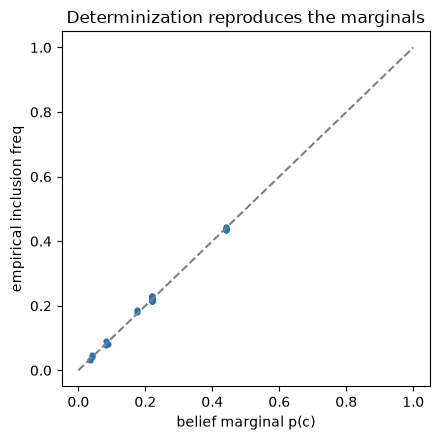

In [15]:
pol = RolloutSearchPolicy(n_determinizations=4000, seed=0)
worlds = pol._determinize(bs)

print("worlds sampled:", len(worlds))
print("opponent hand sizes:", set(len(opp) for opp, _ in worlds))      # all 10

# Madow correctness: empirical inclusion frequency reproduces the belief marginal.
cnt = Counter(c for opp, _ in worlds for c in opp)
emp = np.array([cnt[c] / len(worlds) for c in DECK])
p   = np.array([bs.prob(c) for c in DECK])
unc = (p > 1e-9) & (p < 1 - 1e-9)
print(f"max |empirical - marginal| over uncertain cards: {np.abs(emp - p)[unc].max():.3f}")

plt.figure(figsize=(4.5, 4.5))
plt.scatter(p[unc], emp[unc], s=12)
plt.plot([0, 1], [0, 1], "--", color="grey")
plt.xlabel("belief marginal p(c)"); plt.ylabel("empirical inclusion freq")
plt.title("Determinization reproduces the marginals"); plt.tight_layout(); plt.show()

In [16]:
# Each world partitions the unseen cards into the opponent's hand and the stock.
opp0, stock0 = worlds[0]
print(f"world 0: opp hand = {len(opp0)} cards, stock = {len(stock0)} cards")
print("hand/stock disjoint:", len(set(opp0) & set(stock0)) == 0)

world 0: opp hand = 10 cards, stock = 27 cards
hand/stock disjoint: True


## 3. Monte-Carlo value of a world

Given a fully-observed world $w$, the value $V(a, w)$ is estimated using a rollout. 

The rollout is the process of playing a game state out to its logical conclusion from the current turn onwards. We use a fast, computationally inexpensive base policy to rapidly simulate the remainder of the match to termination and score the knock.

world values: mean=+9.53  std=15.67  range=[-43, 63]


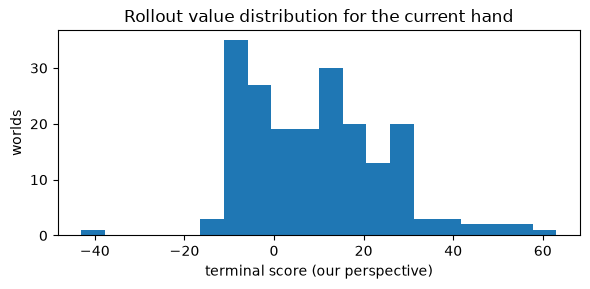

In [17]:
vals = [_rollout(my_hand, opp, list(stock), me_to_move=False) for opp, stock in worlds[:200]]
print(f"world values: mean={np.mean(vals):+.2f}  std={np.std(vals):.2f}  "
      f"range=[{min(vals)}, {max(vals)}]")
plt.figure(figsize=(6, 3))
plt.hist(vals, bins=20)
plt.xlabel("terminal score (our perspective)"); plt.ylabel("worlds")
plt.title("Rollout value distribution for the current hand"); plt.tight_layout(); plt.show()

## 4. Action selection = argmax EV over worlds

In [18]:
demo = RolloutSearchPolicy(n_determinizations=40, seed=0)
worlds_d = demo._determinize(bs)
drawn = worlds_d[0][1][-1]                        # pretend we drew this stock card
hand11 = my_hand + [drawn]

rows = []
for d in hand11:
    kept = [c for c in hand11 if c is not d]
    ev = np.mean([_rollout(kept, opp, list(stock), me_to_move=False)
                  for opp, stock in worlds_d])
    rows.append((str(d), ev))
for s, ev in sorted(rows, key=lambda r: -r[1]):
    print(f"discard {s:4}  EV={ev:+.2f}")
print("\npolicy picks:", demo.choose_discard(hand11, bs, forbidden=None))

discard 4D    EV=+10.82
discard 8C    EV=+10.20
discard 6H    EV=+9.18
discard 5H    EV=+9.07
discard 3H    EV=+8.47
discard 10H   EV=-0.05
discard 10D   EV=-0.05
discard KC    EV=-3.95
discard QC    EV=-5.25
discard JC    EV=-5.40
discard 10C   EV=-5.75

policy picks: 4D


### Does it actually win?
We compare our model against the simple `greedy` algorithm, and the more competent `probabilistic` model.

In order to reach statistical significance, a lot of compute is demanded. As such the results of this code have been included in the table below.

In [19]:
from agent.eval.harness import run_match
import math

N = 400         
ND = 12         # determinizations per discard decision (speed/quality knob)

search = ("search", {"n_determinizations": ND, "knock_samples": 100})

def se(p, n):                      # binomial standard error on the win rate
    return math.sqrt(p * (1 - p) / n)

for opp in ["probabilistic", "greedy"]:
    panel = run_match(search, (opp, {}), n_games=N, alternate_seats=True, n_jobs=-1)
    w = panel["win_rate"]
    z = (w - 0.5) / se(w, N) if 0 < w < 1 else float("nan")
    print(f"search vs {opp:13}  "
          f"win={w:.3f} ±{se(w, N):.3f}  z={z:+.2f}  "
          f"dw={panel['avg_deadwood']:.1f}  "
          f"margin={panel['avg_score_margin']:+.1f}  "
          f"knock={panel['knock_rate']:.2f}  gin={panel['gin_rate']:.2f}  "
          f"undercut(against/by)={panel['undercut_against_rate']:.2f}/{panel['undercut_by_rate']:.2f}")


KeyboardInterrupt: 

#### Result (n=400, ND=32, alternate_seats)

```
search vs probabilistic  win=0.490 ±0.025  z=-0.40  dw=16.3  margin=-1.0  knock=0.49  undercut 0.02/0.02
search vs greedy         win=0.750 ±0.097  z=+2.58  dw=13.1  margin=+9.4  knock=0.65
```
search beats greedy comfortably but sits at parity with the probabilistic baseline

Flat rollout's value estimate is only as good as its playout policy; `_rollout` finishes each determinized world with a naive
player so the move ranking ends up no better than the analytic one-ply policy.


### Stronger playout (`search_smart`)

`search_smart` swaps the naive playout for a more probabilistic one,
keeping a cheap stock-only draw and a cheap can-knock check.

In [ ]:
from agent.eval.harness import run_match
import math, time

# Measured: ND=8/N=60 ~101s (cache warms in real runs). N=400 ~11 min -> runnable.
# This is a small-N probe; raise N=400, ND=16-32 for an SE~0.025 verdict.
ND     = 8       # "simulations" per discard decision (ND=32 ~45min @ N=400)
N      = 60      # games (SE ~0.065 — a true 0.55 edge is invisible at this N)
KS     = 64      # knock_samples, both the search agent and the opponent

def se(p, n): return math.sqrt(p * (1 - p) / n)

smart = ("search_smart", {"n_determinizations": ND, "knock_samples": KS})
opp   = ("probabilistic", {"knock_samples": KS})

t0 = time.time()
panel = run_match(smart, opp, n_games=N, alternate_seats=True, n_jobs=-1)
w = panel["win_rate"]
z = (w - 0.5) / se(w, N) if 0 < w < 1 else float("nan")
print(f"search_smart vs probabilistic  "
      f"win={w:.3f} ±{se(w, N):.3f}  z={z:+.2f}  "
      f"dw={panel['avg_deadwood']:.1f}  margin={panel['avg_score_margin']:+.1f}  "
      f"knock={panel['knock_rate']:.2f}  undercut(against/by)="
      f"{panel['undercut_against_rate']:.2f}/{panel['undercut_by_rate']:.2f}")
print(f"[{time.time()-t0:.0f}s for {N} games at ND={ND}]")

# If win pulls clearly above 0.5 even at this small N, the stronger playout is doing
# something and a truncated-rollout version (fast enough for n=400) is worth building.
# If it's still ~0.5, playout strength isn't the bottleneck -> go to the tree/UCB layer.


## Summary of Results

`RolloutSearchPolicy` selects discards by sampling opponent hand and stock worlds from the belief state.

1. Search outperforms the belief-blind opponent.
`search vs greedy` — win rate 0.75 ± 0.10, z = +2.58 (n = 400, ND = 32).

2. Search reaches parity with the probabilistic baseline.
`search vs probabilistic` — win rate 0.49 ± 0.025, z = −0.40 (n = 400, ND = 32).

3. Stronger playouts do not improve performance.
`search_smart` (using a risk-aware probabilistic discard policy during playout instead of the naive minimum-deadwood policy) achieves a win rate of 0.51 ± 0.050, z = +0.20 (n = 100, ND = 32).

Neither improving playout quality nor increasing the number of determinizations (ND) produces a meaningful improvement against a strong opponent.

`search` differs from the probabilistic baseline only in its discard decision. However, discard appears to be the lowest-leverage decision in Gin Rummy: both policies typically identify and discard the weakest card, resulting in highly similar choices.

These results validate both the belief model and the rollout search implementation. However, they also suggest that discard search alone offers little advantage against a strong baseline.

Future work should instead focus on applying search to the draw and knock decisions, where there is greater potential for strategic impact. Given the substantial computational cost observed in these experiments, implementing a more selective or truncated tree search should also be considered.